In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import csv
import json
import pandas as pd
import geopandas as gpd
import numpy as np


## Matrix with the whole network (OWFs + coast) ##
### This script open csv files with connectivity values from each configuration (farm to farm, farm to coast, etc.) and then plot the matrix ###

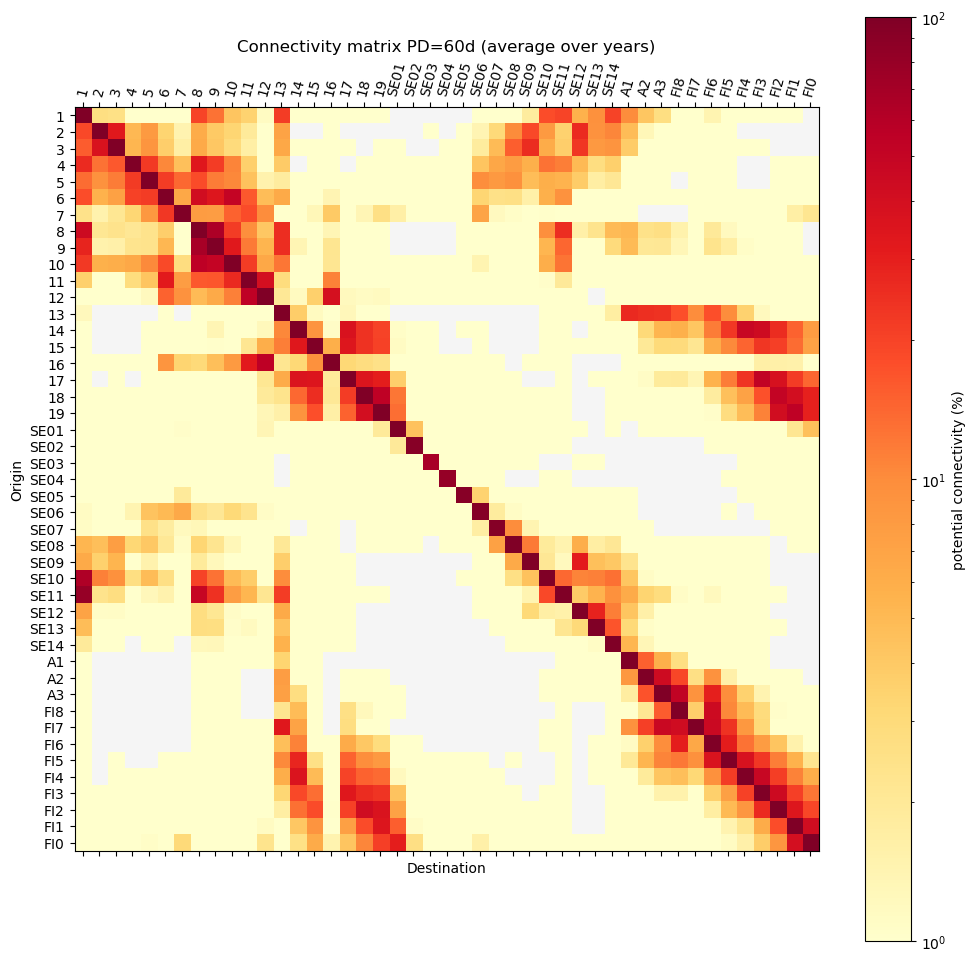

In [48]:
# connectivity matrix farm + coast
farm_file = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
coast_file = '/projappl/project_2018610/data/coastal/nemo_nordic_10-20m_polygons.shp'
gdf_farm = gpd.read_file(farm_file)
gdf_coast = gpd.read_file(coast_file)
                          
PD = 60
nb_f = 19
nb_c = len(gdf_coast)
n_tot = nb_f + nb_c
farmIDs = np.arange(1, nb_f+1)
coastIDs = gdf_coast.sort_values('fid')['ID'].astype(str).tolist() # creating a list of coastal areas sorted by fid
IDs = np.concatenate((farmIDs, coastIDs))

xaxis = np.arange(n_tot)
yaxis = np.arange(n_tot)
A = np.zeros((n_tot, n_tot))

# Opening each csv file to build the matrix

with open('connectivity_matrices/csv/farm_to_farm.csv', mode='r', newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile, delimiter=',')
    f_to_f = list(reader)

    for origin in range(nb_f):
        for dest in range(nb_f):
            A[origin, dest] = float(f_to_f[origin][str(dest)])
    
with open('connectivity_matrices/csv/coast_to_farm.csv', mode='r', newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile, delimiter=',')
    c_to_f = list(reader)

    for origin in range(nb_c):
        for dest in range(nb_f):
            A[19 + origin, dest] = float(c_to_f[origin][str(dest)])
            
with open('connectivity_matrices/csv/farm_to_coast.csv', mode='r', newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile, delimiter=',')
    f_to_c = list(reader)
    
    for origin in range(nb_f):
        for dest in range(nb_c):
            A[origin, 19 + dest] = float(f_to_c[origin][str(dest)])

with open('connectivity_matrices/csv/coast_to_coast.csv', mode='r', newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile, delimiter=',')
    c_to_c = list(reader)

    for origin in range(nb_c):
        for dest in range(nb_c):
            A[19 + origin, 19 + dest] = float(c_to_c[origin][str(dest)])
   
  
fig, ax = plt.subplots(figsize=(12, 12))
A = A
A_masked = np.ma.masked_where(A == 0, A) # mask exact zeros
norm = colors.LogNorm(1, 100)

im = ax.matshow(A, cmap='YlOrRd', norm=norm)
im.cmap.set_bad(color='whitesmoke')

plt.colorbar(im, ax=ax, label='potential connectivity (%)')
plt.yticks(yaxis, IDs)
plt.xticks(xaxis, IDs, rotation=75)
ax.set_xlabel("Destination")
ax.set_ylabel("Origin")
ax.set_title(f'Connectivity matrix PD={PD}d (average over years)')
plt.savefig("connectivity_matrices/connectivity_matrix_farm_and_coast_PD{}.png".format(PD))
plt.show()

## Matrices for each configuration ##
#### For each configuration : building the connectivity matrix + save it as a csv file ####

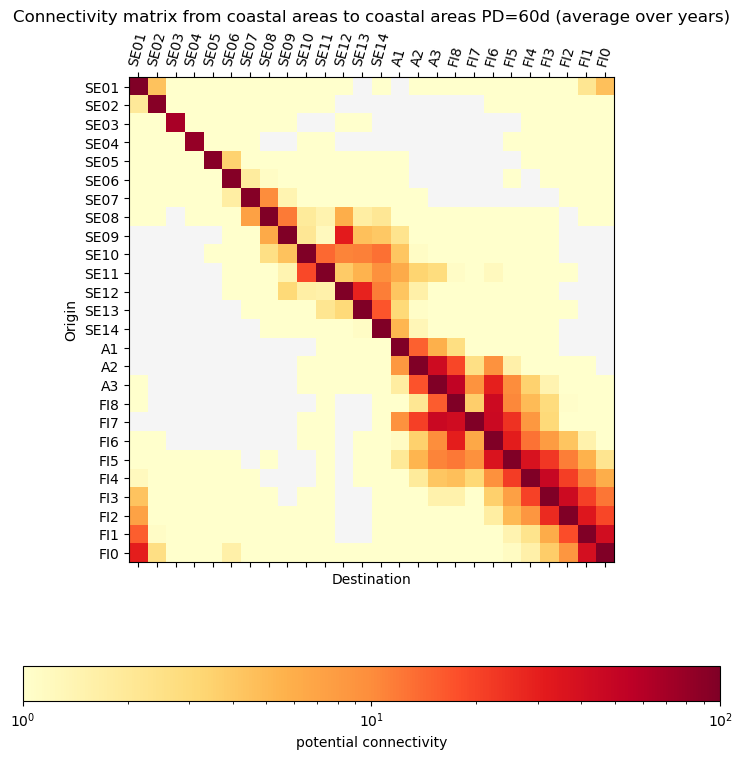

In [52]:
#Connectivity matrix from coast to coast
PD=60
fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD{PD}/from_coast_to_coast/'
coast_file = '/projappl/project_2018610/data/coastal/nemo_nordic_10-20m_polygons.shp'
gdf_coast = gpd.read_file(coast_file)

years = [2012, 2013, 2017, 2018]
nb_c = len(gdf_coast)
coastIDs = gdf_coast.sort_values('fid')['ID'].astype(str).tolist() # creating a list of coastal areas sorted by fid

xaxis = np.arange(nb_c)
yaxis = np.arange(nb_c)
A = np.zeros((nb_c, nb_c))

for year in years:
    for i, ID in enumerate(coastIDs):
    
        file = f'simulation_coast_{ID}_June_September_{year}_PD{PD}_connectivity_to_coast.csv'
    
        with open(fold+file, mode='r', newline='', encoding='utf-8') as csvfile:
            reader = csv.DictReader(csvfile, delimiter=';')
    
            for row in reader:
    
                origin = i
                coast = gdf_coast.loc[gdf_coast['ID'] == row['to']] # Find the coastal area
                dest = coast['fid'].values[0]
                prob = float(row['prob'])
                A[origin, dest] += prob
A = A*100/len(years)   
fig, ax = plt.subplots(figsize=(9, 9))
A_masked = np.ma.masked_where(A == 0, A) # mask exact zeros
norm = colors.LogNorm(1, 100)

im = ax.matshow(A, cmap='YlOrRd', norm=norm)
im.cmap.set_bad(color='whitesmoke')

plt.colorbar(im, ax=ax, label='potential connectivity', location='bottom') 
plt.yticks(yaxis, coastIDs)
plt.xticks(xaxis, coastIDs, rotation=75)
ax.set_xlabel("Destination")
ax.set_ylabel("Origin")
ax.set_title(f'Connectivity matrix from coastal areas to coastal areas PD={PD}d (average over years)')
plt.savefig("connectivity_matrices/coast_to_coast/connectivity_matrix_coast_to_coast_mean_PD{}.png".format(PD)) 
plt.show()

In [47]:
# df = pd.DataFrame(A)
# df.to_csv('connectivity_matrices/csv/coast_to_coast.csv')

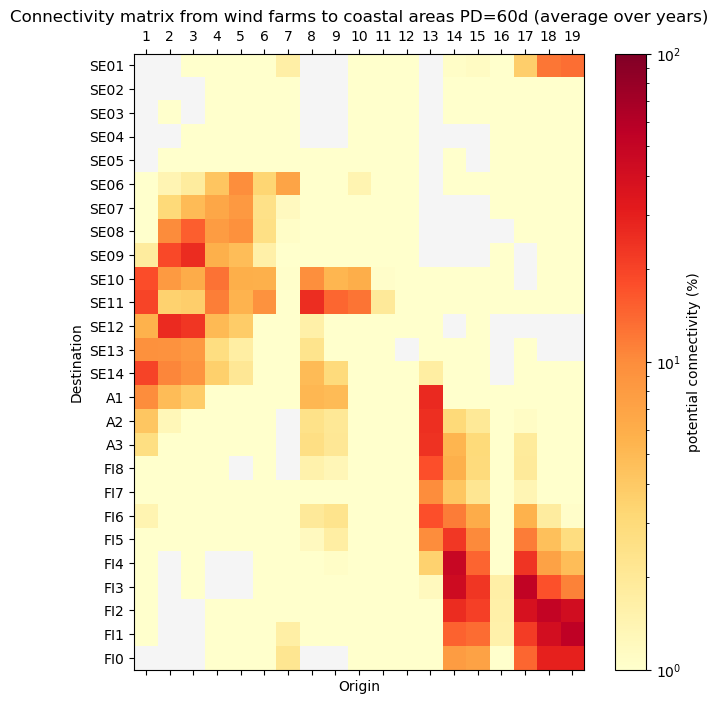

In [26]:
#Connectivity matrix from farm to coast
PD=60
fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD{PD}/from_farm_to_coast/'
farm_file = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
coast_file = '/projappl/project_2018610/data/coastal/nemo_nordic_10-20m_polygons.shp'
gdf_farm = gpd.read_file(farm_file)
gdf_coast = gpd.read_file(coast_file)

years = [2012, 2013, 2017, 2018]
nb_f = 19
nb_c = len(gdf_coast)
farmIDs = np.arange(1, nb_f+1)
coastIDs = gdf_coast.sort_values('fid')['ID'].astype(str).tolist() # creating a list of coastal areas sorted by fid

xaxis = np.arange(nb_f)
yaxis = np.arange(nb_c)
A = np.zeros((nb_c, nb_f))

for year in years:
    for ID in farmIDs:
    
        file = f'simulation_farm_{ID}_June_September_{year}_connectivity_to_coast.csv'
    
        with open(fold+file, mode='r', newline='', encoding='utf-8') as csvfile:
            reader = csv.DictReader(csvfile, delimiter=';')
    
            for row in reader:
    
                origin = int(row['from']) - 1
                coast = gdf_coast.loc[gdf_coast['ID'] == row['to']] # Find the coastal area
                dest = coast['fid'].values[0]
                prob = float(row['prob'])
                A[dest, origin] += prob
A = A*100/len(years)   
fig, ax = plt.subplots(figsize=(8, 8))
A_masked = np.ma.masked_where(A == 0, A) # mask exact zeros
norm = colors.LogNorm(1, 100)

im = ax.matshow(A, cmap='YlOrRd', norm=norm)
im.cmap.set_bad(color='whitesmoke')

plt.colorbar(im, ax=ax, label='potential connectivity (%)')
plt.yticks(yaxis, coastIDs)
plt.xticks(xaxis, farmIDs)
ax.set_xlabel("Origin")
ax.set_ylabel("Destination")
ax.set_title(f'Connectivity matrix from wind farms to coastal areas PD={PD}d (average over years)')
plt.savefig("connectivity_matrices/farm_to_coast/connectivity_matrix_farm_to_coast_mean_PD{}.png".format(PD))
plt.show()

In [27]:
# df = pd.DataFrame(np.transpose(A))
# df.to_csv('connectivity_matrices/csv/farm_to_coast.csv')

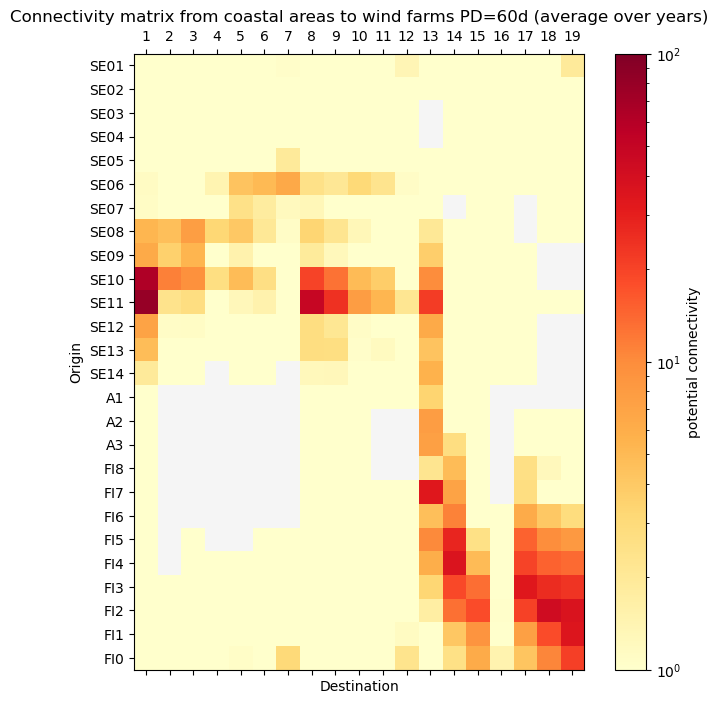

In [28]:
# Connectivity matrix from coast to farm
PD=60
fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD{PD}/from_coast_to_farm/'
farm_file = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
coast_file = '/projappl/project_2018610/data/coastal/nemo_nordic_10-20m_polygons.shp'
gdf_farm = gpd.read_file(farm_file)
gdf_coast = gpd.read_file(coast_file)

years = [2012, 2013, 2017, 2018]
nb_f = 19
nb_c = len(gdf_coast)
farmIDs = np.arange(1, nb_f+1)
coastIDs = gdf_coast.sort_values('fid')['ID'].astype(str).tolist() # creating a list of coastal areas sorted by fid

xaxis = np.arange(nb_f)
yaxis = np.arange(nb_c)
A = np.zeros((nb_c, nb_f))

for year in years:   
    for i, ID in enumerate(coastIDs):
    
        file = f'simulation_coast_{ID}_June_September_{year}_connectivity.csv'
        # file = f'simulation_coast_{ID}_June_September_{year}_PD{PD}_connectivity.csv'
    
        with open(fold+file, mode='r', newline='', encoding='utf-8') as csvfile:
            reader = csv.DictReader(csvfile, delimiter=';')
    
            for row in reader:
    
                origin = i
                dest = int(row['to']) - 1
                prob = float(row['prob'])
                A[origin, dest] += prob
A = A*100/len(years)
fig, ax = plt.subplots(figsize=(8, 8))

A_masked = np.ma.masked_where(A == 0, A) # mask exact zeros
norm = colors.LogNorm(1, 100)

im = ax.matshow(A, cmap='YlOrRd', norm=norm)
im.cmap.set_bad(color='whitesmoke')

plt.colorbar(im, ax=ax, label='potential connectivity')
plt.xticks(xaxis, farmIDs)
plt.yticks(yaxis, coastIDs)
ax.set_xlabel("Destination")
ax.set_ylabel("Origin")
ax.set_title(f'Connectivity matrix from coastal areas to wind farms PD={PD}d (average over years)')
plt.savefig("connectivity_matrices/coast_to_farm/connectivity_matrix_coast_to_farm_mean_PD{}.png".format(PD))
plt.show()

In [29]:
# df = pd.DataFrame(A)
# df.to_csv('connectivity_matrices/csv/coast_to_farm.csv')

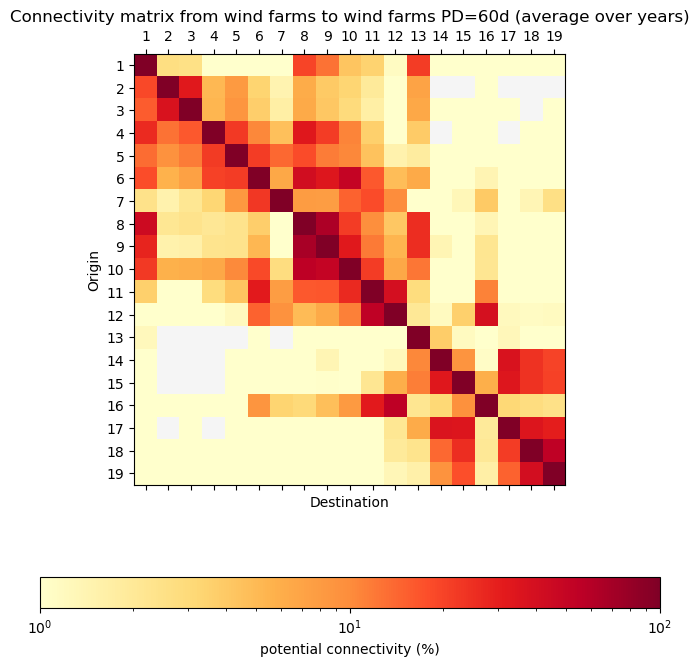

In [32]:
# Average over all the years
PD = 60
fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD{PD}/from_farm_to_farm/'
years = [2012, 2013, 2017, 2018]
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
A = np.zeros((19, 19))

for year in years :
    for ID in farmIDs:
    
        # file = f'simulation_farm_{ID}_June_September_{year}_PD{PD}_connectivity.csv' #for PD=30d or PD=5d
        file = f'simulation_farm_{ID}_June_September_{year}_connectivity.csv' #for PD=60d only
    
        with open(fold+file, mode='r', newline='', encoding='utf-8') as csvfile:
            reader = csv.DictReader(csvfile, delimiter=';')
    
            for row in reader:
    
                origin = int(row['from']) - 1
                dest = int(row['to']) - 1
                prob = float(row['prob'])
                A[origin, dest] += prob
            
A = A*100/len(years)

fig, ax = plt.subplots(figsize=(8, 8))

# im = ax.matshow(A, cmap='YlOrRd')

A_masked = np.ma.masked_where(A == 0, A) # mask exact zeros
norm = colors.LogNorm(1, 100)

im = ax.matshow(A, cmap='YlOrRd', norm=norm)
im.cmap.set_bad(color='whitesmoke')

plt.colorbar(im, ax=ax, label='potential connectivity (%)', location='bottom') 
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Destination")
ax.set_ylabel("Origin")
ax.set_title(f'Connectivity matrix from wind farms to wind farms PD={PD}d (average over years)')
plt.savefig(f"connectivity_matrices/farm_to_farm/connectivity_matrix_farm_to_farm_mean_PD{PD}.png")
plt.show()

In [31]:
# df = pd.DataFrame(A)
# df.to_csv('connectivity_matrices/csv/farm_to_farm.csv')

#### Year comparison ####

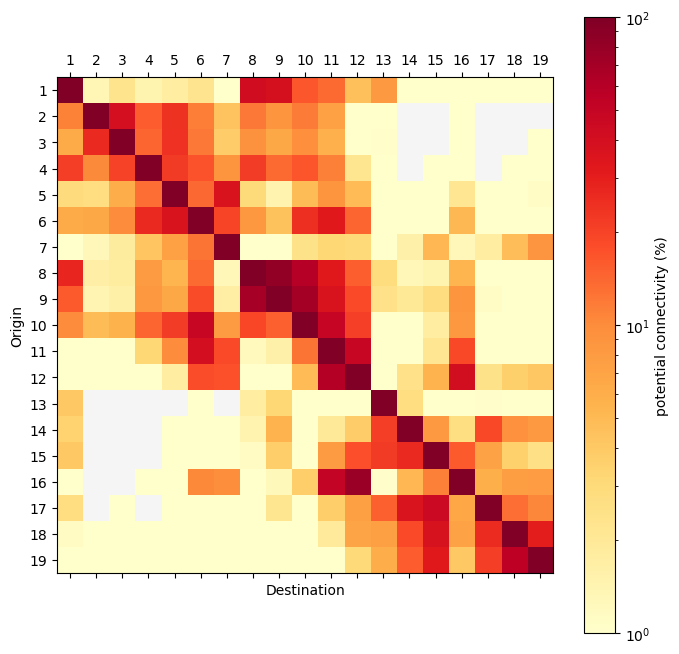

In [44]:
# Connectivity matrices from farm to farm (individual matrix for each year)

fold = '/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD60/from_farm_to_farm/'
shape_file = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
gdf = gpd.read_file(shape_file)

year = 2018
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
A = np.zeros((19, 19))

for ID in farmIDs:

    file = f'simulation_farm_{ID}_June_September_{year}_connectivity.csv'

    with open(fold+file, mode='r', newline='', encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile, delimiter=';')

        for row in reader:

            origin = int(row['from']) - 1
            dest = int(row['to']) - 1
            prob = float(row['prob'])
            A[origin, dest] = prob

fig, ax = plt.subplots(figsize=(8, 8))

A = A*100

A_masked = np.ma.masked_where(A == 0, A) # mask exact zeros
norm = colors.LogNorm(1, 100)

im = ax.matshow(A, cmap='YlOrRd', norm=norm)
im.cmap.set_bad(color='whitesmoke')

plt.colorbar(im, ax=ax, label='potential connectivity (%)')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Destination")
ax.set_ylabel("Origin")
# ax.set_title(f'Connectivity matrix {year}')
plt.savefig("Selection_of_figures/connectivity_matrix_{}.png".format(year))  #connectivity_matrices/farm_to_farm/
plt.show()